--- Loading Integrated Dataset ---
Data Loaded: 1074189 rows, 22 columns


/var/folders/vj/jkftb76576g6gntjkl2_4b0w0000gn/T/ipykernel_31209/542265691.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Prevalence (%)', y='Disease', data=prev_df, palette='viridis')


Saved: 01_disease_prevalence.png
Saved: 02_correlation_matrix.png


/var/folders/vj/jkftb76576g6gntjkl2_4b0w0000gn/T/ipykernel_31209/542265691.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Asthma Status', y='Avg_AQI', data=plot_df, palette='Set2', showfliers=False)


Saved: 03_environmental_impact.png
Saved: 04_health_trends.png

--- Exploratory Analysis Complete. Figures saved in 'plots/' folder. ---


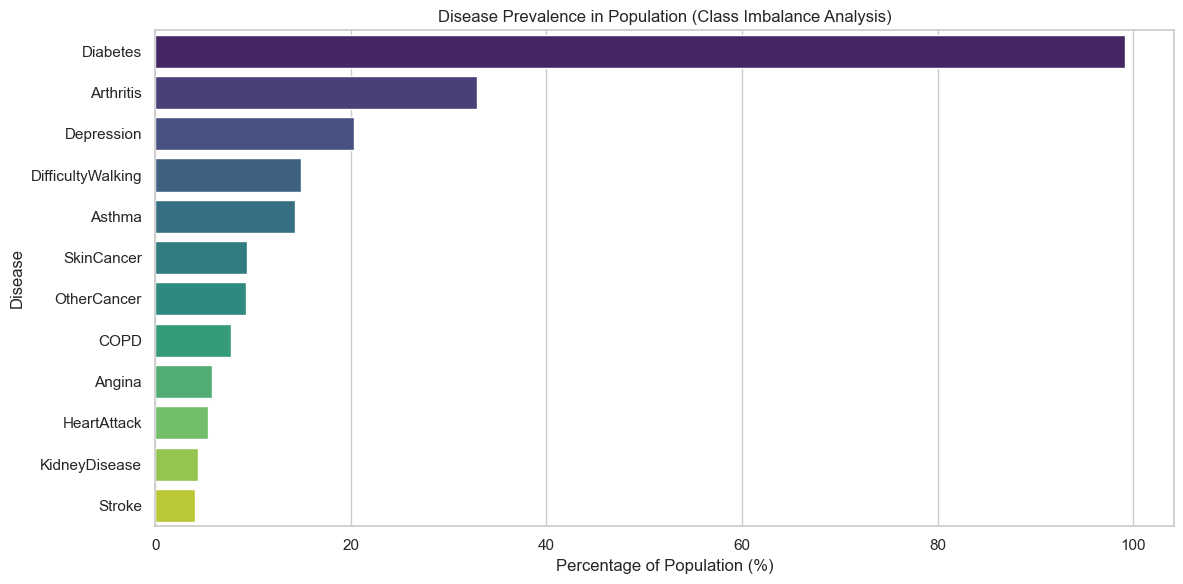

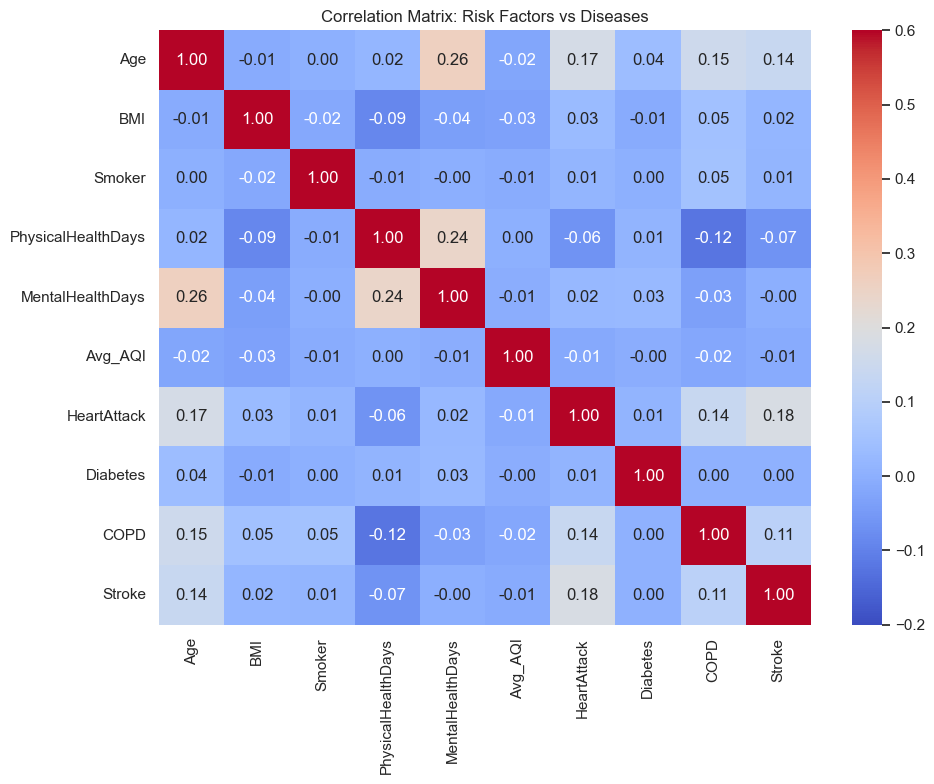

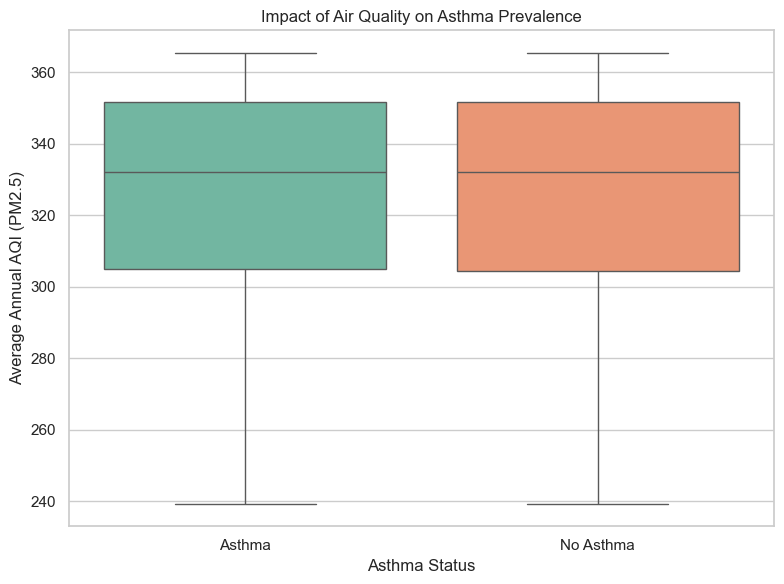

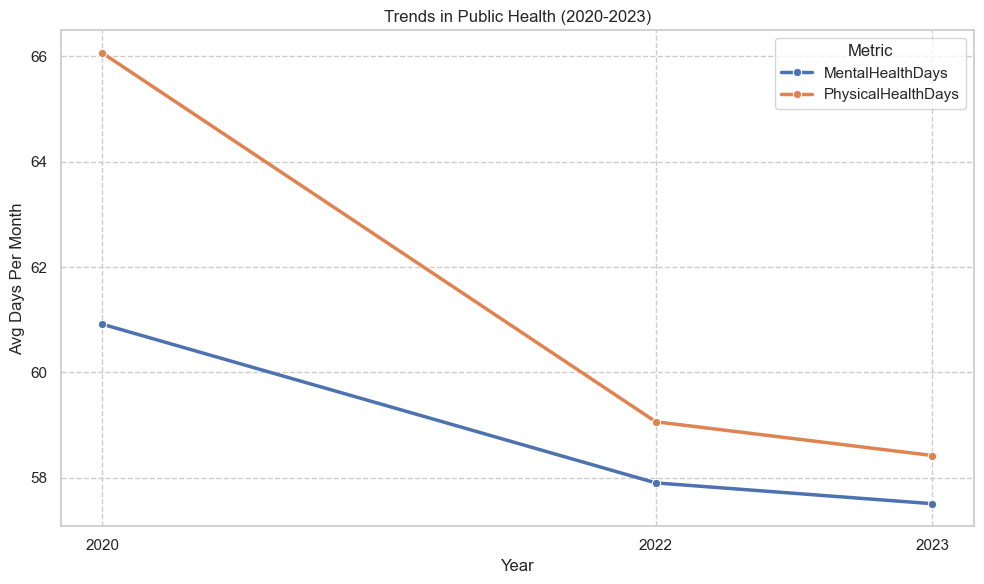

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set professional style for Report Figures
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Create plots directory
os.makedirs('../plots', exist_ok=True)

# ==========================================
# 1. LOAD DATA
# ==========================================
print("--- Loading Integrated Dataset ---")
try:
    df = pd.read_csv('../data/Processed/multi_year_health_data.csv')
except FileNotFoundError:
    try:
        df = pd.read_csv('data/Processed/multi_year_health_data.csv')
    except:
        # Final fallback for different folder structures
        df = pd.read_csv('../data/processed/multi_year_health_data.csv')

print(f"Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# ==========================================
# 2. DISEASE PREVALENCE (Class Imbalance)
# ==========================================
# This proves why "Accuracy" is a bad metric and why we used "Recall"
targets = ['HeartAttack', 'Angina', 'Stroke', 'Asthma', 'SkinCancer', 
           'OtherCancer', 'COPD', 'Depression', 'KidneyDisease', 
           'Diabetes', 'Arthritis', 'DifficultyWalking']

prevalence = []
for t in targets:
    if t in df.columns:
        prev = df[t].mean() * 100
        prevalence.append({'Disease': t, 'Prevalence (%)': prev})

prev_df = pd.DataFrame(prevalence).sort_values('Prevalence (%)', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Prevalence (%)', y='Disease', data=prev_df, palette='viridis')
plt.title('Disease Prevalence in Population (Class Imbalance Analysis)')
plt.xlabel('Percentage of Population (%)')
plt.tight_layout()
plt.savefig('../plots/01_disease_prevalence.png')
print("Saved: 01_disease_prevalence.png")

# ==========================================
# 3. CORRELATION HEATMAP (Risk Factors)
# ==========================================
# Select key columns for correlation
cols_to_corr = ['Age', 'BMI', 'Smoker', 'PhysicalHealthDays', 'MentalHealthDays', 'Avg_AQI', 
                'HeartAttack', 'Diabetes', 'COPD', 'Stroke']

# Filter only existing columns
cols_to_corr = [c for c in cols_to_corr if c in df.columns]

plt.figure(figsize=(10, 8))
corr_matrix = df[cols_to_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.2, vmax=0.6)
plt.title('Correlation Matrix: Risk Factors vs Diseases')
plt.tight_layout()
plt.savefig('../plots/02_correlation_matrix.png')
print("Saved: 02_correlation_matrix.png")

# ==========================================
# 4. ENVIRONMENTAL IMPACT (The "Heterogeneous" Proof)
# ==========================================
# Does Air Quality (AQI) affect Asthma or COPD?
if 'Avg_AQI' in df.columns and 'Asthma' in df.columns:
    plt.figure(figsize=(8, 6))
    
    # Create a nice label
    plot_df = df.copy()
    plot_df['Asthma Status'] = plot_df['Asthma'].map({0: 'No Asthma', 1: 'Asthma'})
    
    # Boxplot showing AQI distribution for healthy vs sick
    sns.boxplot(x='Asthma Status', y='Avg_AQI', data=plot_df, palette='Set2', showfliers=False)
    plt.title('Impact of Air Quality on Asthma Prevalence')
    plt.ylabel('Average Annual AQI (PM2.5)')
    plt.tight_layout()
    plt.savefig('../plots/03_environmental_impact.png')
    print("Saved: 03_environmental_impact.png")

# ==========================================
# 5. TEMPORAL TRENDS (Critical Thinking)
# ==========================================
# Did Mental Health get worse from 2020 to 2023?
if 'Year' in df.columns and 'MentalHealthDays' in df.columns:
    plt.figure(figsize=(10, 6))
    
    # Group by Year
    trend = df.groupby('Year')[['MentalHealthDays', 'PhysicalHealthDays']].mean().reset_index()
    
    # Melt for plotting
    trend_melt = trend.melt('Year', var_name='Metric', value_name='Avg Days Per Month')
    
    sns.lineplot(x='Year', y='Avg Days Per Month', hue='Metric', data=trend_melt, marker='o', linewidth=2.5)
    plt.title('Trends in Public Health (2020-2023)')
    plt.xticks(trend['Year'].unique()) # Ensure integers
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.savefig('../plots/04_health_trends.png')
    print("Saved: 04_health_trends.png")

print("\n--- Exploratory Analysis Complete. Figures saved in 'plots/' folder. ---")

--- Loading Data for EDA ---
Loaded 1074189 rows. Using 10k sample for plots.
Generating Prevalence Plot...
Generating Correlation Matrix...


/var/folders/vj/jkftb76576g6gntjkl2_4b0w0000gn/T/ipykernel_31209/2160951527.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(prev_data.values()), y=list(prev_data.keys()), palette='viridis')


Generating Interaction Plot...
Skipped Interaction Plot due to data grouping error: 9.0
Generating State Analysis...


/var/folders/vj/jkftb76576g6gntjkl2_4b0w0000gn/T/ipykernel_31209/2160951527.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_risk.values * 100, y=state_risk.index, palette='magma')



--- EDA Complete. All plots saved to '../plots/' ---


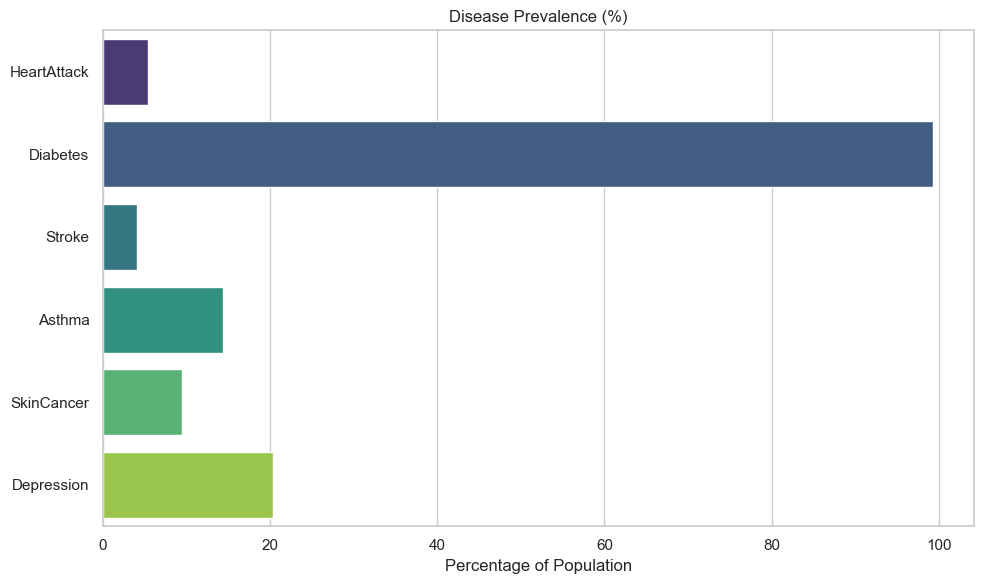

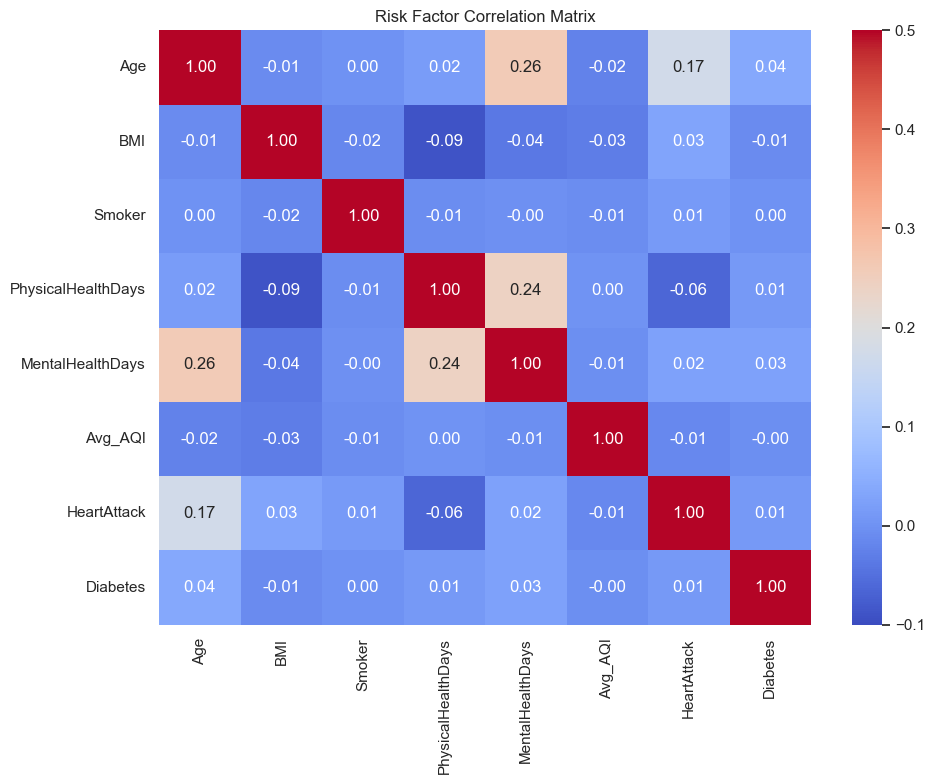

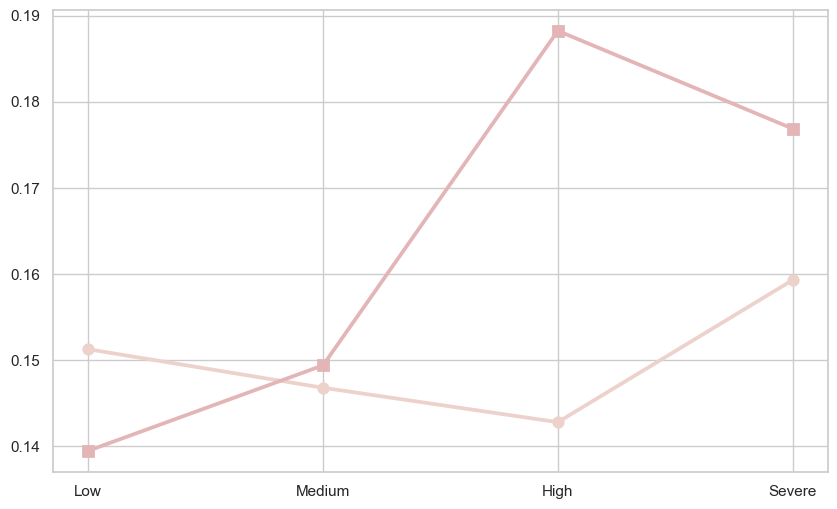

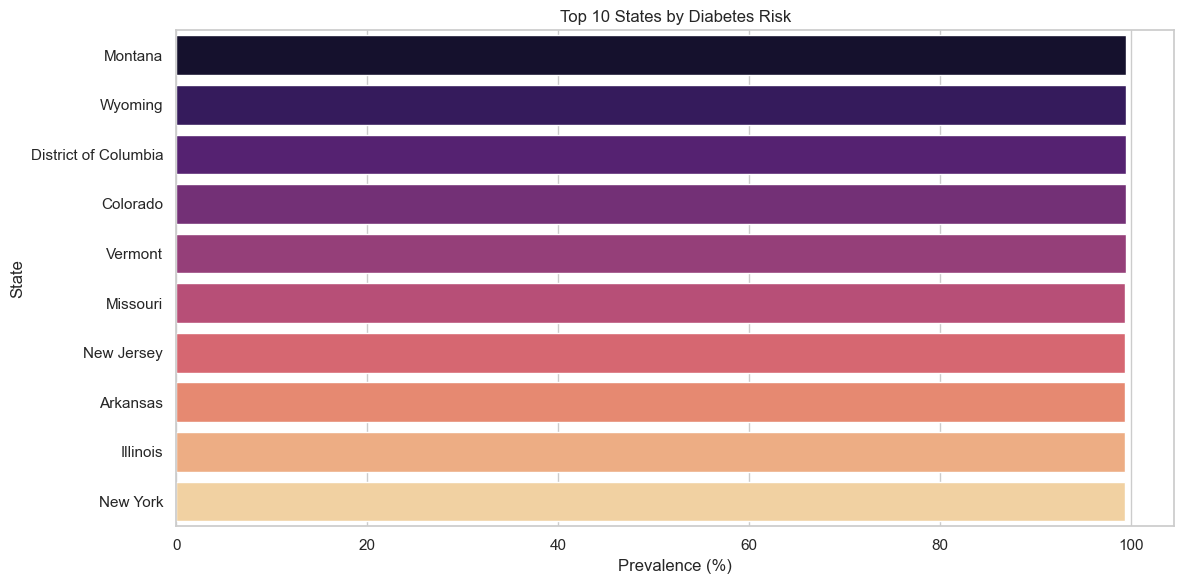

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set professional style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('../plots', exist_ok=True)

# ==========================================
# 1. LOAD DATA
# ==========================================
print("--- Loading Data for EDA ---")
# Robust path handling
try:
    path = '../data/Processed/multi_year_health_data.csv'
    if not os.path.exists(path): path = 'data/Processed/multi_year_health_data.csv'
    df = pd.read_csv(path)
except:
    print("Error: Could not find dataset. Check paths.")
    df = pd.DataFrame()

# Sample for scatterplots/complex viz to avoid memory crashes
if not df.empty:
    df_sample = df.sample(n=min(10000, len(df)), random_state=42).copy()
    print(f"Loaded {len(df)} rows. Using 10k sample for plots.")

# ==========================================
# 2. PLOT 1: PREVALENCE (Bar Chart)
# ==========================================
if not df.empty:
    print("Generating Prevalence Plot...")
    targets = ['HeartAttack', 'Diabetes', 'Stroke', 'Asthma', 'SkinCancer', 'Depression']
    # Calculate prevalence only for columns that exist
    prev_data = {t: df[t].mean()*100 for t in targets if t in df.columns}
    
    if prev_data:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=list(prev_data.values()), y=list(prev_data.keys()), palette='viridis')
        plt.title('Disease Prevalence (%)')
        plt.xlabel('Percentage of Population')
        plt.tight_layout()
        plt.savefig('../plots/01_prevalence.png')

# ==========================================
# 3. PLOT 2: CORRELATION MATRIX (Heatmap)
# ==========================================
if not df.empty:
    print("Generating Correlation Matrix...")
    cols = ['Age', 'BMI', 'Smoker', 'PhysicalHealthDays', 'MentalHealthDays', 'Avg_AQI', 'HeartAttack', 'Diabetes']
    # Filter valid columns
    valid_cols = [c for c in cols if c in df.columns]
    
    plt.figure(figsize=(10, 8))
    corr = df[valid_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.1, vmax=0.5)
    plt.title('Risk Factor Correlation Matrix')
    plt.tight_layout()
    plt.savefig('../plots/02_correlation.png')

# ==========================================
# 4. PLOT 3: ENVIRONMENTAL INTERACTION (The Fix)
# ==========================================
# This is where your code crashed. This version uses qcut for safety.
if 'Avg_AQI' in df.columns and 'Asthma' in df.columns and not df_sample.empty:
    print("Generating Interaction Plot...")
    plt.figure(figsize=(10, 6))
    
    # FIX: Ensure data types are clean
    df_sample['Asthma'] = pd.to_numeric(df_sample['Asthma'], errors='coerce')
    
    # Create simpler bins (Quartiles) - guaranteed to work
    # Labels: Low Pollution -> High Pollution
    try:
        df_sample['Pollution_Level'] = pd.qcut(df_sample['Avg_AQI'], q=4, labels=['Low', 'Medium', 'High', 'Severe'])
        
        # Plot: We rely on standard Seaborn aggregation now (safer than manual groupby)
        sns.pointplot(
            data=df_sample, 
            x='Pollution_Level', 
            y='Asthma', 
            hue='Smoker', 
            markers=['o', 's'],
            errorbar=None # Removes error bars to prevent math errors on small samples
        )
        plt.title('Combined Effect: Air Quality & Smoking on Asthma Risk')
        plt.ylabel('Asthma Probability')
        plt.tight_layout()
        plt.savefig('../plots/03_interaction.png')
        print("Success: Interaction Plot Saved.")
        
    except Exception as e:
        print(f"Skipped Interaction Plot due to data grouping error: {e}")

# ==========================================
# 5. PLOT 4: REGIONAL MAP PROXY
# ==========================================
if 'State' in df.columns and 'Diabetes' in df.columns:
    print("Generating State Analysis...")
    state_risk = df.groupby('State')['Diabetes'].mean().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=state_risk.values * 100, y=state_risk.index, palette='magma')
    plt.title('Top 10 States by Diabetes Risk')
    plt.xlabel('Prevalence (%)')
    plt.tight_layout()
    plt.savefig('../plots/04_regional_risk.png')

print("\n--- EDA Complete. All plots saved to '../plots/' ---")